In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon
from scipy.ndimage import gaussian_filter

from sklearn.model_selection import train_test_split

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil, sys
from pathlib import Path
import json
import subprocess

import thetaflow as thf
# import modelnn2 as thf
print("Thetaflow version: {}".format(thf.__version__))

sys.path.append("../")
import mpscr_models as mpscr
import pwexp
import gndr_utils as utils
import mps

E0000 00:00:1784006373.102787   19756 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784006373.139057   19756 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784006373.409224   19756 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784006373.409258   19756 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784006373.409262   19756 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784006373.409266   19756 computation_placer.cc:177] computation placer already registered. Please check linka

Thetaflow version: 0.0.35


I0000 00:00:1784006379.103416   19756 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4323 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784006379.151338   19756 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4323 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784006379.153009   19756 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4323 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784006379.158123   19756 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4323 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5


# Notebook

In this notebook, we load the traditional MNIST dataset in order to benchmark and study the performance of our new model under images as predicting variables.

This dataset is very well known, consisting on the basic identification of numbers in images. We will be considering that the number disposed in each image corresponds to 10 times the susceptible probability of a simulated individual. That is, if the image corresponds to a 3, then the simulated time associated to it will have a 0.3 probability of being susceptible to death.

With that simulation, we aim to study the capacity of the MPScr to select the true, generating model out of all alternative proposals and also study some asymptotic properties of such model.

In [60]:
def generate_synthetic_brain(omega, size = 200):
    """
        Generates a synthetic 200x200 brain mask with Alzheimer's-like atrophy.
        
        Parameters:
            omega (float): Disease severity from 0.0 (Healthy) to 1.0 (Severe AD).
            size (int): The dimension of the output image (size x size).
    """
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y)
    
    # Define the base "Healthy" brain shape (an oval/ellipse)
    # R_cortex represents the distance from the center
    R_cortex = np.sqrt((X / 0.95)**2 + (Y / 0.85)**2)
    
    # Procedural Noise for Cortical Rugosity
    # We create random noise and heavily blur it to make it smooth and organic
    raw_noise = np.random.rand(size, size)
    smooth_noise = gaussian_filter(raw_noise, sigma = 4)
    # Normalize the noise to have a mean of 0 and std of 1
    smooth_noise = (smooth_noise - np.mean(smooth_noise)) / np.std(smooth_noise)
    
    # Atrophy to the Cortex Boundary
    # Omega dictates how aggressively the noise "eats" into the outer edge
    atrophy_factor = omega * 0.1 + 0.01
    distorted_cortex = R_cortex + atrophy_factor * smooth_noise
    cortex_mask = distorted_cortex < 1.0
    
    # Ventricular Enlargement (Holes in the center)
    # Ventricles grow larger and more distorted as omega increases
    ventricle_base_width = 0.30 + (omega * 0.25)
    ventricle_base_height = 0.15 + (omega * 0.15)
    R_ventricles = np.sqrt((X / ventricle_base_width)**2 + (Y / ventricle_base_height)**2)
    
    # Different noise map for the ventricles so they evolve independently
    v_raw_noise = np.random.rand(size, size)
    v_noise = gaussian_filter(v_raw_noise, sigma = 4)
    v_noise = (v_noise - np.mean(v_noise)) / np.std(v_noise)

    v_atrophy_factor = omega * 0.2
    distorted_ventricles = R_ventricles + v_atrophy_factor * v_noise
    ventricle_mask = distorted_ventricles < 1.0
    
    # Brain tissue is the cortex minus the ventricles
    brain_mask = cortex_mask & ~ventricle_mask

    # Obtain the continuous blob that composes our "brain"
    tissue_gradient = np.clip(1.0 - distorted_cortex, 0, 1)
    
    # Tissue Texture: Higher-frequency noise for "folds"
    t_raw_noise = np.random.rand(size, size)
    texture_noise = gaussian_filter(t_raw_noise, sigma = 3) # Lower sigma = finer details
    texture_noise = (texture_noise - np.mean(texture_noise)) / np.std(texture_noise)
    
    # Combine and normalize strictly between 0 and 1
    tissue_density = tissue_gradient + 0.3 * texture_noise
    min_val = np.min(tissue_density[brain_mask])
    max_val = np.max(tissue_density[brain_mask])
    tissue_density = (tissue_density - min_val) / (max_val - min_val)
    
    # Quantize into 4 discrete gray tones: 0.25, 0.50, 0.75, 1.00
    # (tissue_density * 3) ranges from 0 to 3. Rounding and math shifts it to our 4 bins.
    quantized_tissue = np.round(tissue_density * 5)
    quantized_tissue = (quantized_tissue + 1) / 4.0 

    # final_brain = np.where(brain_mask, quantized_tissue, 0.0)
    
    # Initialize an all-black background for the ventricles
    final_brain = np.zeros((size, size), dtype=np.float32)
    
    # Paint the tissue
    final_brain[brain_mask] = quantized_tissue[brain_mask]
    
    # Paint the ventricles white (brightest tone)
    # We use (cortex_mask & ventricle_mask) to ensure we don't accidentally paint 
    # outside the brain if a severe omega pushes the ventricles too far outward.
    white_intensity = 0.2 # Ensures it is the absolute brightest feature
    final_brain[cortex_mask & ventricle_mask] = white_intensity

    # Normalize the image pixels to be between 0 and 1
    final_brain = final_brain / np.max(final_brain)
    
    return final_brain.astype(np.float32)

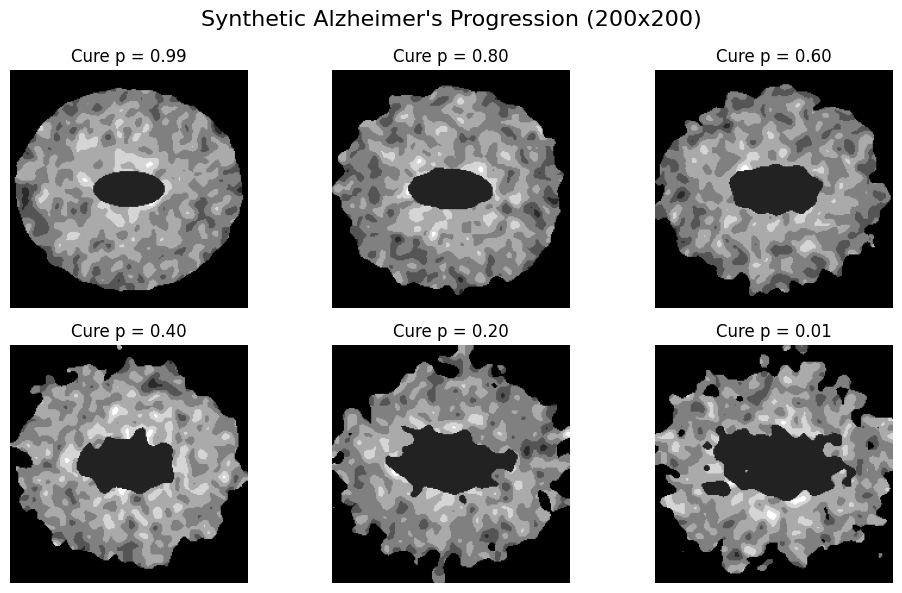

In [61]:
# Different severity levels for brain generation
omegas = [0.01, 0.2, 0.4, 0.6, 0.8, 0.99]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("Synthetic Alzheimer's Progression (200x200)", fontsize=16)

for ax, omega in zip(axes.flatten(), omegas):
    brain = generate_synthetic_brain(omega)
    ax.imshow(brain, cmap = 'gray')
    ax.set_title("Cure p = {:.2f}".format(1-omega))
    
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
def generate_brain_images(p_values, size = 200):
    """
        Given different p values for the susceptible probabilities of each patient, we generate their respective brain images
        following the overall literature convention on Alzheimer's brain morphology: atrophied sulci and larger central venticles.
    """
    n = p_values.shape[0]
    brain_imgs = np.zeros( (n, size, size) )
    for j, p in enumerate(p_values):
        brain_imgs[j, :, :] = generate_synthetic_brain(p, size = size)
    return brain_imgs

In [5]:
n = 1500
R = 200

np.random.seed(10)
p = np.random.uniform(low = 0.01, high = 0.9, size = n)
brain_imgs = generate_brain_images(p)
cure_p = 1-p

In [6]:
train_size = 0.7
img_train, img_test, cure_p_train, cure_p_test = train_test_split(brain_imgs, cure_p, train_size = train_size)

print("Train size: {} / {} ({:.0f}%)".format(img_train.shape[0], n, train_size*100))
print("Test size: {} / {} ({:.0f}%)".format(img_test.shape[0], n, (1-train_size)*100))

Train size: 1050 / 1500 (70%)
Test size: 450 / 1500 (30%)


In [7]:
def generate_lifetimes(model_spec, cure_p, alpha, s, censor_low = 0.0, censor_high = 10.0):
    """
        Given the generating distribution for the lifetimes under the MPScr and the cure probabilities for each patient,
        generate both lifetimes and censoring indicators for all patients.
    
        Parameters:
            model_spec: Configuration object for the MPScr model, all distribution objects considered are defined in mpscr_models.py
            cure_p: Vector of cure probabilities
    """
    n = cure_p.shape[0]
    q = model_spec.fixed_q
    phi = model_spec.phi
    C = model_spec.C
    C_inv = model_spec.C_inv
    
    theta = model_spec.C_inv( model_spec.a0(q) / cure_p, q )
    p_min = model_spec.p_min(q)
    p_max = model_spec.p_max(q)
    
    y_true = np.repeat(np.inf, n)
    obs_y = y_true.copy()
    
    # Draw U for all patients independently of cured status
    u = np.random.uniform( size = n )
    # If u is lesser than the cure probability, consider those patients as cured
    susceptible_mask = u >= cure_p

    # S_pop^{-1} for susceptible patients
    u_susceptible = u[susceptible_mask]
    theta_susceptible = theta[susceptible_mask]    
    ppf_arg = 1.0 - phi(C_inv(C(theta_susceptible, q) * u_susceptible, q), q) / phi(theta_susceptible, q)
    y_true[susceptible_mask] = pwexp.ppf(ppf_arg, alpha, s)

    y_censor = np.random.uniform(size = n, low = censor_low, high = censor_high)

    # Define observed lifetimes as 1
    delta = np.zeros(n, dtype = int)
    delta[y_true <= y_censor] = 1
    obs_y[delta == 1] = y_true[delta == 1]
    obs_y[delta == 0] = y_censor[delta == 0]

    cured_status = np.ones(n, dtype=int)
    cured_status[susceptible_mask] = 0
    
    return obs_y, delta, cured_status

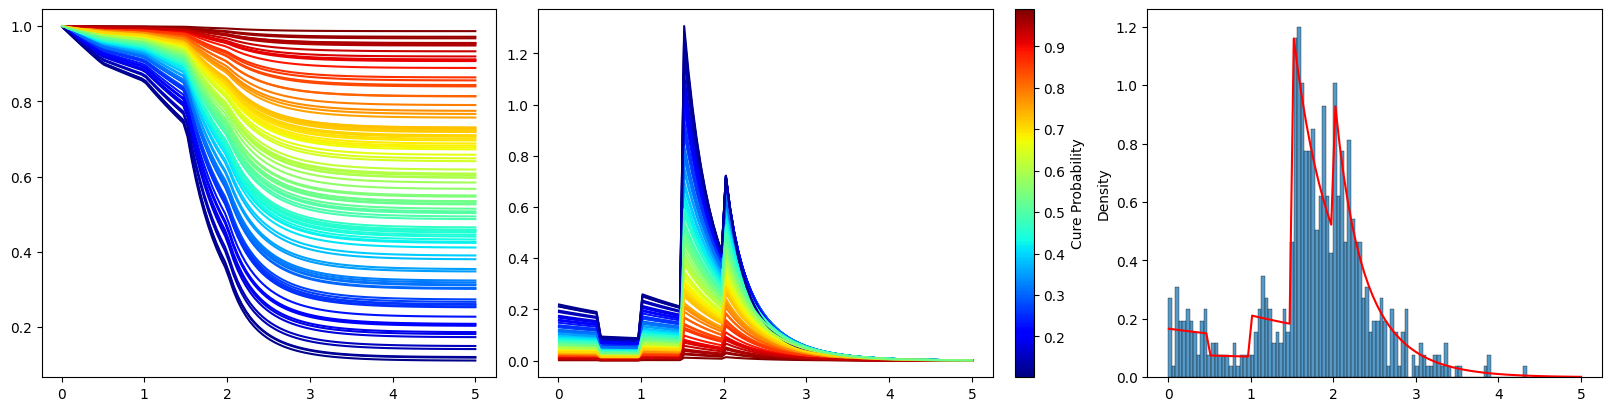

In [18]:
alpha = np.array([0.1, 0.05, 0.15, 1, 2])
s = np.array([0,0.5,1,1.5,2])
# s = np.array([0, 2.062, 3.36, 4.495, 6.32, 12.2])
# alpha = np.array([0.02872308, 0.04870019, 0.10390695, 0.16946955, 0.5868493, 0.5868493])

n = 1500
np.random.seed(10)
p = np.random.uniform(low = 0.01, high = 0.9, size = n)
cure_p = 1-p

poisson_spec = mpscr.MPSPoisson()
# poisson_spec = mpscr.MPSBinomial(1)
y, delta, cured = generate_lifetimes(poisson_spec, cure_p, alpha, s, censor_low = 0.0, censor_high = 25)

# t = np.linspace(0.01, np.max(y), 100)
t = np.linspace(0.01, 5, 100)

cure_p_t = cure_p[:,None]
dens_pop = pwexp.pdf(t, alpha, s)

Spop_curves_t = poisson_spec.Spop(t, cure_p, 0.0, alpha, s).numpy()
fpop_curves_t = poisson_spec.fpop(t, cure_p, 0.0, alpha, s).numpy()

Spop_curves_t_susceptibles = Spop_curves_t[:, (cured == 0) & (delta == 1)]
fpop_curves_t_susceptibles = fpop_curves_t[:, (cured == 0) & (delta == 1)]
cure_p_susceptibles = cure_p[(cured == 0) & (delta == 1)]

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (16,4), layout='constrained')

norm = mcolors.Normalize(vmin = np.min(cure_p), vmax = np.max(cure_p))
cmap = plt.get_cmap('jet')
sm = cm.ScalarMappable(cmap = cmap, norm = norm)
sm.set_array([])

for i in range(100):
    mapped_color = cmap(norm(cure_p[i]))
    # plt.plot(t, Spop_curves_t_susceptibles[:,i], color = mapped_color, alpha = 0.2)
    # ax.plot(t, fpop_curves_t_susceptibles[:,i], color = mapped_color)
    ax[0].plot(t, Spop_curves_t[:,i], color = mapped_color)
    ax[1].plot(t, fpop_curves_t[:,i], color = mapped_color)

fig.colorbar(sm, ax=ax[1], label='Cure Probability')

dens_pop = fpop_curves_t_susceptibles / (1-cure_p_susceptibles)
dens_pop_mixture = np.mean(dens_pop, axis = 1)

sns.histplot(y[(cured == 0) & (delta == 1)], bins = 100, stat = "density", ax = ax[2])
ax[2].plot(t, dens_pop_mixture, color = "red")

plt.show()

As it can be seen above, all generating functions seem to be working as expected. To properly generate the simulation data, we fix a similar pattern to what has been previously reported in papers that studied Xie & Yu's data on the OASIS-3 database. We consider a slower survival decay for the first years, followed by a quicker decline. The respective plots can be seen below.

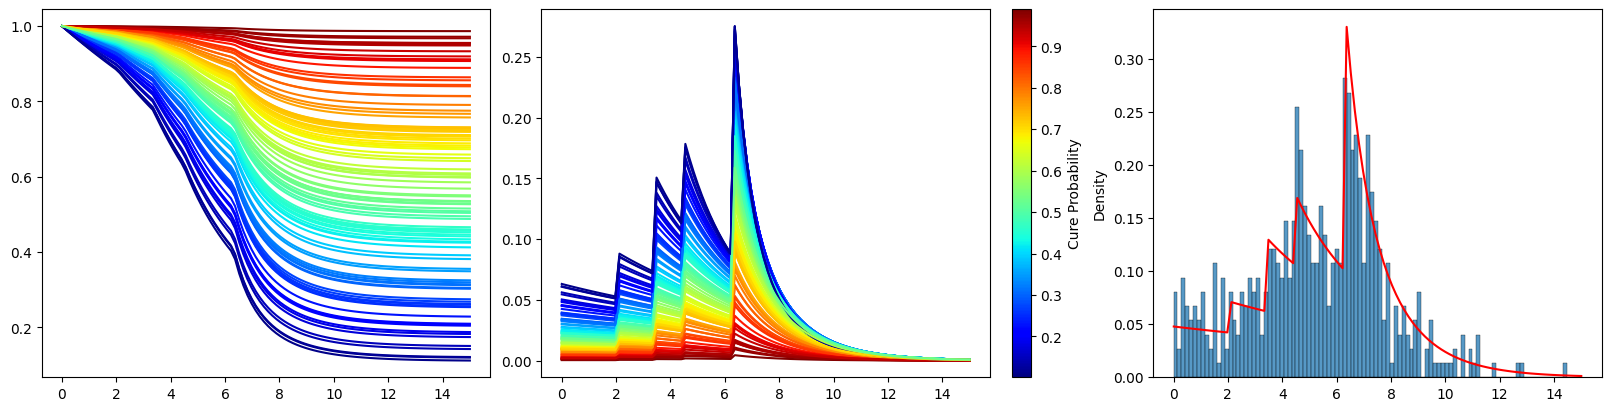

In [20]:
s = np.array([0, 2.062, 3.36, 4.495, 6.32, 12.2])
alpha = np.array([0.02872308, 0.04870019, 0.10390695, 0.16946955, 0.5868493, 0.5868493])

n = 1500
np.random.seed(10)
p = np.random.uniform(low = 0.01, high = 0.9, size = n)
cure_p = 1-p

poisson_spec = mpscr.MPSPoisson()
# poisson_spec = mpscr.MPSBinomial(1)
y, delta, cured = generate_lifetimes(poisson_spec, cure_p, alpha, s, censor_low = 0.0, censor_high = 25)

t = np.linspace(0.01, 15, 100)

cure_p_t = cure_p[:,None]
dens_pop = pwexp.pdf(t, alpha, s)

Spop_curves_t = poisson_spec.Spop(t, cure_p, 0.0, alpha, s).numpy()
fpop_curves_t = poisson_spec.fpop(t, cure_p, 0.0, alpha, s).numpy()

Spop_curves_t_susceptibles = Spop_curves_t[:, (cured == 0) & (delta == 1)]
fpop_curves_t_susceptibles = fpop_curves_t[:, (cured == 0) & (delta == 1)]
cure_p_susceptibles = cure_p[(cured == 0) & (delta == 1)]

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (16,4), layout='constrained')

norm = mcolors.Normalize(vmin = np.min(cure_p), vmax = np.max(cure_p))
cmap = plt.get_cmap('jet')
sm = cm.ScalarMappable(cmap = cmap, norm = norm)
sm.set_array([])

for i in range(100):
    mapped_color = cmap(norm(cure_p[i]))
    # plt.plot(t, Spop_curves_t_susceptibles[:,i], color = mapped_color, alpha = 0.2)
    # ax.plot(t, fpop_curves_t_susceptibles[:,i], color = mapped_color)
    ax[0].plot(t, Spop_curves_t[:,i], color = mapped_color)
    ax[1].plot(t, fpop_curves_t[:,i], color = mapped_color)

fig.colorbar(sm, ax=ax[1], label='Cure Probability')

dens_pop = fpop_curves_t_susceptibles / (1-cure_p_susceptibles)
dens_pop_mixture = np.mean(dens_pop, axis = 1)

sns.histplot(y[(cured == 0) & (delta == 1)], bins = 100, stat = "density", ax = ax[2])
ax[2].plot(t, dens_pop_mixture, color = "red")

plt.show()

Naturally, there is also the problem of censoring. We choose to fix the censoring distribution to be a $U(0, \tau)$, where $\tau$ is tailored according to the desired proportion of censorship in the dataset.

In [43]:
s = np.array([0, 2.062, 3.36, 4.495, 6.32, 12.2])
alpha = np.array([0.02872308, 0.04870019, 0.10390695, 0.16946955, 0.5868493, 0.5868493])

n = 1500
np.random.seed(10)
p = np.random.uniform(low = 0.01, high = 0.9, size = n)
cure_p = 1-p

tau = 15
poisson_spec = mpscr.MPSPoisson()
y, delta, cured = generate_lifetimes(poisson_spec, cure_p, alpha, s, censor_low = 0.0, censor_high = tau)
print("Proportion of cured: {:.2f}%".format(np.mean(cured)*100) )
print("Proportion of censorship: {:.2f}%".format(np.mean(1-delta)*100) )

Proportion of cured: 56.60%
Proportion of censorship: 72.47%


In [ ]:
poisson_model, results_cure_poisson = fit_model("poisson", img_train, y_train, delta_train, img_test, y_test, delta_test)
results_cure_poisson["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_train"], delta_train)
results_cure_poisson["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_test"], delta_test)